In [1]:
# installing what we need - groq for the api calls, pydantic for validating the model output
!pip install -q groq pydantic pandas matplotlib seaborn tabulate
print("done installing")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 3.6 MB/s eta 0:00:00
done installing


In [2]:
import os
import json
import getpass
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel, Field
from typing import Literal
from groq import Groq

# paste your groq key when prompted, it's free to get one from console.groq.com
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("groq api key: ")

client = Groq(api_key=os.environ["GROQ_API_KEY"])
print("client is ready")

groq api key: ··········
client is ready


In [3]:
# just checking what models this key actually has access to before we hardcode anything
available_models = [m.id for m in client.models.list().data if "whisper" not in m.id.lower()]
print(available_models)

['allam-2-7b', 'meta-llama/llama-prompt-guard-2-22m', 'canopylabs/orpheus-v1-english', 'openai/gpt-oss-20b', 'meta-llama/llama-prompt-guard-2-86m', 'openai/gpt-oss-120b', 'canopylabs/orpheus-arabic-saudi', 'openai/gpt-oss-safeguard-20b', 'qwen/qwen3.8-27b']


In [4]:
# this is the schema the model has to fill out for every response it grades
# using pydantic so we can validate the json coming back instead of just trusting it
class LLMEvaluationResult(BaseModel):
    faithfulness_score: int = Field(
        ...,
        ge=1,
        le=5,
        description="1 = made up / not supported by context at all, 5 = fully backed by the context"
    )
    relevancy_score: int = Field(
        ...,
        ge=1,
        le=5,
        description="1 = doesn't answer the question, 5 = answers it directly"
    )
    hallucination_detected: bool = Field(
        ...,
        description="true if the answer includes a claim the context doesn't support"
    )
    hallucination_risk: Literal["Low", "Medium", "High"] = Field(
        ...,
        description="overall risk level"
    )
    evaluation_reasoning: str = Field(
        ...,
        description="short explanation for why it got these scores"
    )

print("schema defined")

schema defined


In [5]:
# a handful of test cases to run through the grader
# a couple are "normal" (answer matches context) and a couple are deliberately wrong/hallucinated
# so we can check the grader actually catches them
benchmark_data = [
    {
        "test_id": "TC-001",
        "category": "Financial Reporting",
        "question": "What was the company's Q3 revenue growth and operating margin?",
        "context": "In Q3 2025, Acme Corp reported revenue of $450M, representing a 14% year-over-year increase. Operating margin improved to 18.5% compared to 16.2% in Q3 2024.",
        "candidate_answer": "Acme Corp generated $450 million in revenue during Q3 2025, an increase of 14% year-over-year, while operating margin expanded to 18.5%."
    },
    {
        "test_id": "TC-002",
        "category": "Financial Reporting (Hallucination Test)",
        "question": "What was Acme Corp's net profit in Q3 2025?",
        "context": "In Q3 2025, Acme Corp reported revenue of $450M and an operating income of $83.25M. Net profit figures will be finalized in the upcoming 10-K audit filing.",
        "candidate_answer": "Acme Corp reported a net profit of $95 million in Q3 2025, showing strong performance across global markets."
    },
    {
        "test_id": "TC-003",
        "category": "Customer Policy",
        "question": "Can customers return opened electronics after 14 days?",
        "context": "Electronics may be returned within 30 days of purchase in original packaging. Opened software and digital media are strictly non-refundable.",
        "candidate_answer": "Yes, customers can return opened electronics within 30 days of purchase provided they have the original packaging."
    },
    {
        "test_id": "TC-004",
        "category": "Customer Policy (Hallucination Test)",
        "question": "What is the return window for digital software downloads?",
        "context": "Electronics may be returned within 30 days of purchase in original packaging. Opened software and digital media are strictly non-refundable.",
        "candidate_answer": "Digital software downloads can be returned within 7 business days if you have proof of purchase."
    },
    {
        "test_id": "TC-005",
        "category": "Technical Specifications",
        "question": "What database systems are supported in version 4.2?",
        "context": "Version 4.2 introduces native connectors for PostgreSQL 14+, MySQL 8.0, and Snowflake. Support for Oracle DB has been deprecated.",
        "candidate_answer": "Version 4.2 supports PostgreSQL 14+, MySQL 8.0, and Snowflake. Note that Oracle DB support is deprecated."
    },
    {
        "test_id": "TC-006",
        "category": "Relevancy Evasion Test",
        "question": "How do I configure the API timeout parameter in the client SDK?",
        "context": "To set the request timeout, pass `timeout=30` into the Client constructor. The default value is 10 seconds. Retries are enabled by default up to 3 attempts.",
        "candidate_answer": "The client SDK includes automatic retries up to 3 attempts with exponential backoff to handle connection drops smoothly."
    }
]

benchmark_df = pd.DataFrame(benchmark_data)
print(f"loaded {len(benchmark_df)} test cases, {benchmark_df['category'].nunique()} categories")
display(benchmark_df[["test_id", "category", "question"]])

loaded 6 test cases, 6 categories


,test_id,category,question
0,TC-001,Financial Reporting,What was the company's Q3 revenue growth and o...
1,TC-002,Financial Reporting (Hallucination Test),What was Acme Corp's net profit in Q3 2025?
2,TC-003,Customer Policy,Can customers return opened electronics after ...
3,TC-004,Customer Policy (Hallucination Test),What is the return window for digital software...
4,TC-005,Technical Specifications,What database systems are supported in version...
5,TC-006,Relevancy Evasion Test,How do I configure the API timeout parameter i...


In [6]:
# figure out which model to actually use.
# the models.list() endpoint returns everything on the account, including stuff
# that isn't a normal chat model (whisper, tts, guard/safety models, etc), so a plain
# "just filter out whisper and guard" check isn't enough - canopylabs/orpheus-v1-english
# slipped through last time and blew up with a "terms acceptance required" error.
# so: filter out the obvious non-chat models by keyword, then actually try each
# candidate with a tiny request instead of trusting the list blindly.

exclude_keywords = ["whisper", "guard", "tts", "orpheus", "safeguard"]
all_models = [
    m.id for m in client.models.list().data
    if not any(kw in m.id.lower() for kw in exclude_keywords)
]

# known-good production chat models on groq, in order of preference
preferred = [
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "openai/gpt-oss-120b",
    "openai/gpt-oss-20b",
]

# preferred models first (if available on this key), then whatever else is left
candidates = [m for m in preferred if m in all_models] + [m for m in all_models if m not in preferred]

ACTIVE_MODEL = None
for candidate in candidates:
    try:
        client.chat.completions.create(
            model=candidate,
            messages=[{"role": "user", "content": "ping"}],
            max_tokens=1,
        )
        ACTIVE_MODEL = candidate
        break
    except Exception as e:
        print(f"skipping {candidate}: {e}")

if ACTIVE_MODEL is None:
    raise RuntimeError("none of the available models accepted a test request")

print(f"using model: {ACTIVE_MODEL}")

def evaluate_response(question: str, context: str, answer: str) -> dict:
    """
    Sends one question/context/answer triple to the model and asks it to grade the answer.
    Returns a dict matching the LLMEvaluationResult schema.
    """
    prompt = f"""
You are an expert AI Quality Assurance & LLM Evaluation Specialist.
Audit the following candidate response against the reference context and user question.

### INPUT DATA:
[USER QUESTION]: {question}
[REFERENCE CONTEXT]: {context}
[CANDIDATE RESPONSE]: {answer}

### EVALUATION RUBRIC:
1. Faithfulness (1-5):
   - 5: Every single claim is explicitly backed by the context.
   - 3: Partially supported; minor extrapolations.
   - 1: Fabricated claims or contradicts the context entirely.
2. Relevancy (1-5):
   - 5: Fully and directly answers the user prompt.
   - 3: Answers tangentially or misses the core question.
   - 1: Completely ignores the question.
3. Hallucination:
   - Mark hallucination_detected = True if ANY claim is made that cannot be deduced from the context.
   - Assign hallucination_risk as "Low", "Medium", or "High".
4. Reasoning:
   - Provide a clear, objective explanation citing specific discrepancies.

Return ONLY a valid JSON object matching this schema:
{{
  "faithfulness_score": <int 1-5>,
  "relevancy_score": <int 1-5>,
  "hallucination_detected": <bool true/false>,
  "hallucination_risk": "<Low|Medium|High>",
  "evaluation_reasoning": "<string>"
}}
"""

    response = client.chat.completions.create(
        model=ACTIVE_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        response_format={"type": "json_object"}
    )

    raw_content = response.choices[0].message.content

    # sometimes the model wraps the json in markdown fences even when we ask it not to, strip that out
    cleaned_content = raw_content.strip()
    if cleaned_content.startswith("```json"):
        cleaned_content = cleaned_content[7:-3].strip()
    elif cleaned_content.startswith("```"):
        cleaned_content = cleaned_content[3:-3].strip()

    parsed_json = json.loads(cleaned_content)
    validated_result = LLMEvaluationResult(**parsed_json)
    return validated_result.model_dump()

print("evaluate_response() ready")

using model: openai/gpt-oss-120b
evaluate_response() ready


In [7]:
print("running the benchmark, this'll take a bit...\n")

results = []
for idx, row in benchmark_df.iterrows():
    print(f"grading [{row['test_id']}] ({row['category']})")
    eval_metrics = evaluate_response(row["question"], row["context"], row["candidate_answer"])

    # merge the original row with whatever scores came back
    combined_record = {**row, **eval_metrics}

    # pass/fail rule: needs faithfulness >= 4, relevancy >= 4, and no hallucination flagged
    combined_record["passed_audit"] = (
        eval_metrics["faithfulness_score"] >= 4 and
        eval_metrics["relevancy_score"] >= 4 and
        not eval_metrics["hallucination_detected"]
    )
    results.append(combined_record)

audit_df = pd.DataFrame(results)
print("\ndone")

display(audit_df[["test_id", "category", "faithfulness_score", "relevancy_score", "hallucination_detected", "hallucination_risk", "passed_audit"]])

running the benchmark, this'll take a bit...

grading [TC-001] (Financial Reporting)
grading [TC-002] (Financial Reporting (Hallucination Test))
grading [TC-003] (Customer Policy)
grading [TC-004] (Customer Policy (Hallucination Test))
grading [TC-005] (Technical Specifications)
grading [TC-006] (Relevancy Evasion Test)

done


,test_id,category,faithfulness_score,relevancy_score,hallucination_detected,hallucination_risk,passed_audit
0,TC-001,Financial Reporting,5,5,False,Low,True
1,TC-002,Financial Reporting (Hallucination Test),1,5,True,High,False
2,TC-003,Customer Policy,4,5,True,Medium,False
3,TC-004,Customer Policy (Hallucination Test),1,5,True,High,False
4,TC-005,Technical Specifications,5,5,False,Low,True
5,TC-006,Relevancy Evasion Test,3,1,True,Medium,False


In [8]:
total_tests = len(audit_df)
pass_count = audit_df["passed_audit"].sum()
pass_rate = (pass_count / total_tests) * 100
hallucination_rate = (audit_df["hallucination_detected"].sum() / total_tests) * 100
avg_faithfulness = audit_df["faithfulness_score"].mean()
avg_relevancy = audit_df["relevancy_score"].mean()

print("-" * 50)
print("summary")
print("-" * 50)
print(f"total test cases      : {total_tests}")
print(f"pass rate             : {pass_rate:.1f}% ({pass_count}/{total_tests})")
print(f"hallucination rate    : {hallucination_rate:.1f}%")
print(f"avg faithfulness score: {avg_faithfulness:.2f} / 5.0")
print(f"avg relevancy score   : {avg_relevancy:.2f} / 5.0")
print("-" * 50)

--------------------------------------------------
summary
--------------------------------------------------
total test cases      : 6
pass rate             : 33.3% (2/6)
hallucination rate    : 66.7%
avg faithfulness score: 3.17 / 5.0
avg relevancy score   : 4.33 / 5.0
--------------------------------------------------


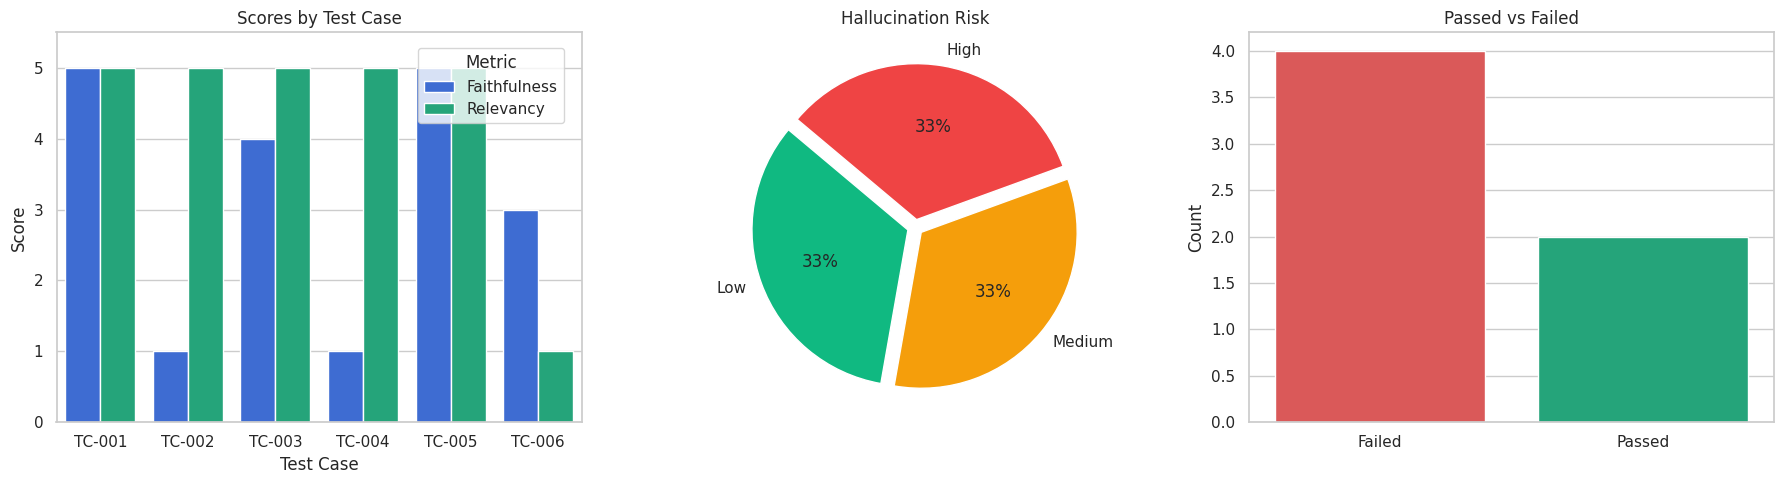

saved dashboard to evaluation_dashboard.png


In [9]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# scores per test case
scores_df = pd.melt(
    audit_df,
    id_vars=["test_id"],
    value_vars=["faithfulness_score", "relevancy_score"],
    var_name="Metric",
    value_name="Score"
)
scores_df["Metric"] = scores_df["Metric"].str.replace("_score", "").str.title()

sns.barplot(data=scores_df, x="test_id", y="Score", hue="Metric", palette=["#2563EB", "#10B981"], ax=axes[0])
axes[0].set_title("Scores by Test Case", fontsize=12)
axes[0].set_ylim(0, 5.5)
axes[0].set_ylabel("Score")
axes[0].set_xlabel("Test Case")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98), title="Metric", frameon=True)

# hallucination risk breakdown
risk_counts = audit_df["hallucination_risk"].value_counts().reindex(["Low", "Medium", "High"], fill_value=0)
colors = ["#10B981", "#F59E0B", "#EF4444"]
axes[1].pie(risk_counts, labels=risk_counts.index, autopct="%1.0f%%", startangle=140, colors=colors, explode=(0.05, 0.05, 0.05))
axes[1].set_title("Hallucination Risk", fontsize=12)

# pass vs fail
sns.countplot(data=audit_df, x="passed_audit", order=[False, True], hue="passed_audit", hue_order=[False, True], palette={False: "#EF4444", True: "#10B981"}, legend=False, ax=axes[2])
axes[2].set_title("Passed vs Failed", fontsize=12)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Failed", "Passed"])
axes[2].set_ylabel("Count")
axes[2].set_xlabel("")

plt.tight_layout()
plt.savefig("evaluation_dashboard.png", dpi=300)
plt.show()
print("saved dashboard to evaluation_dashboard.png")

In [10]:
# print out details for whatever failed so we can actually see why
failed_cases = audit_df[~audit_df["passed_audit"]]

for _, row in failed_cases.iterrows():
    print(f"[{row['test_id']}] {row['category']}")
    print(f"  question  : {row['question']}")
    print(f"  answer    : {row['candidate_answer']}")
    print(f"  scores    : faithfulness={row['faithfulness_score']}/5, relevancy={row['relevancy_score']}/5, risk={row['hallucination_risk']}")
    print(f"  reasoning : {row['evaluation_reasoning']}\n")

audit_df.to_csv("llm_evaluation_audit_report.csv", index=False)
print("exported full report to llm_evaluation_audit_report.csv")

[TC-002] Financial Reporting (Hallucination Test)
  question  : What was Acme Corp's net profit in Q3 2025?
  answer    : Acme Corp reported a net profit of $95 million in Q3 2025, showing strong performance across global markets.
  scores    : faithfulness=1/5, relevancy=5/5, risk=High
  reasoning : The candidate claims Acme Corp had a net profit of $95 million in Q3 2025, but the reference context provides no net‑profit figure and explicitly states the net profit will be finalized in the upcoming 10‑K filing. This claim is not supported by the context and directly contradicts it, constituting a hallucination. Hence faithfulness is 1. The response does directly address the user’s question about net profit, so relevancy is high. Because the fabricated figure is a clear false statement, the hallucination risk is high.

[TC-003] Customer Policy
  question  : Can customers return opened electronics after 14 days?
  answer    : Yes, customers can return opened electronics within 30 days of